In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

In [ ]:
oecd_better_life_index = pd.read_csv("datasets/oecd_better_life_index.csv", thousands=',')

# O link que está no livro deu erro 404, então eu busquei os dados de PIB per capita no World Bank Open Data
wbod_pib_per_capita = pd.read_csv(
    "datasets/world_bank_open_data_pib_per_capita.csv", 
    thousands=',', 
    delimiter=',',       
    encoding='utf-8-sig',
    skiprows=4           # Pula as primeiras 4 linhas de lixo
)

def prepare_country_stats(oecd_bli, pib_per_capita):
    # Filtrar o BLI para pegar apenas o índice de "Satisfação com a Vida" (Life Satisfaction)
    # E focar apenas no valor total (Inequality: Total)
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    
    # Pivotar a tabela para que os indicadores virem colunas e os países virem linhas
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="OBS_VALUE")
    
    # Renomear a coluna do PIB para facilitar o merge
    pib_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    
    # Definir o país como índice também no PIB para unir as tabelas
    pib_per_capita.set_index("Country Name", inplace=True)
    
    # Unir as duas tabelas usando o índice (País)
    full_country_stats = pd.merge(left=oecd_bli, right=pib_per_capita,
                                  left_index=True, right_index=True)
    
    # Ordenar pelo PIB para ficar organizado
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    
    # Remover os outliers (países muito ricos ou pobres que fogem da linha)
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    keep_indices = list(set(range(36)) - set(remove_indices))
    
    # Retornar apenas as colunas que interessam para o gráfico: PIB e Satisfação
    return full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]

country_stats = prepare_country_stats(oecd_better_life_index, wbod_pib_per_capita)

X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]

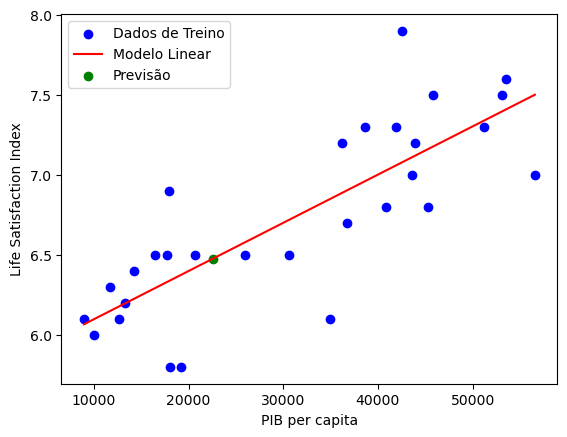

In [ ]:
# Seleção do Modelo de Regressão Linear
model = sklearn.linear_model.LinearRegression()

# Treinamento do Modelo
model.fit(X, y)

# Previsão do novo dado
X_novo = [[22587]]
y_previsto = model.predict(X_novo)

# Plot dos dados de treino (pontos azuis)
plt.scatter(X, y, color='blue', label="Dados de Treino")

# Plot da reta de regressão (linha vermelha)
plt.plot(X, model.predict(X), color='red', label="Modelo Linear")

# Plot do novo dado (ponto verde)
plt.scatter(X_novo, y_previsto, color='green', label="Previsão")

# Nomes dos eixos
plt.xlabel("PIB per capita")
plt.ylabel("Life Satisfaction Index")

plt.legend()
plt.show()

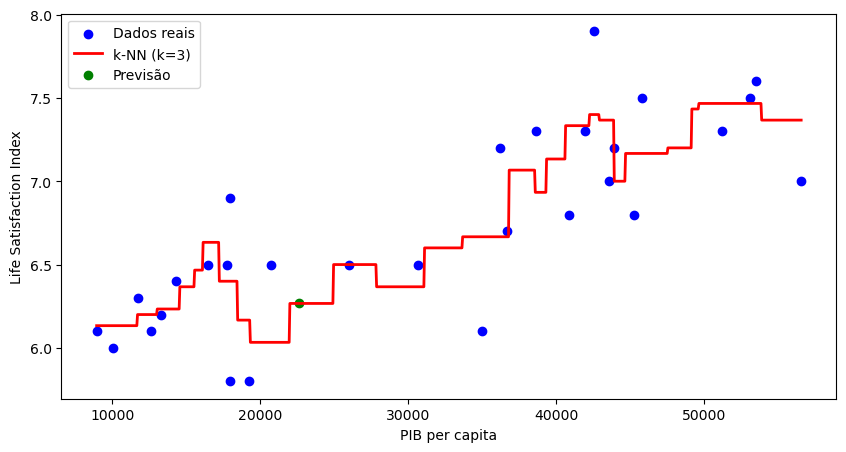

In [ ]:
# Seleção do Modelo K-Nearest Neighbors
model = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)

# Treinamento do Modelo
model.fit(X, y)

# Gerar uma sequência densa de pontos no eixo X para ver a "curva" do k-NN
X_range = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)

# Plotagem
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label="Dados reais")

# Plot da curva do k-NN
plt.plot(X_range, model.predict(X_range), color='red', linewidth=2, label="k-NN (k=3)")

# Plot do novo dado (ponto verde)
plt.scatter(X_novo, model.predict(X_novo), color='green', label="Previsão")

# Nomes dos eixos
plt.xlabel("PIB per capita")
plt.ylabel("Life Satisfaction Index")

plt.legend()
plt.show()